<a href="https://colab.research.google.com/github/AwadZafar5493/Pytorch-Tutorial/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Convert MNIST Image Files into a Tensor of 4-Dimenstions (Number of images, heights, width, color channel)
transform = transforms.ToTensor()

In [3]:
# Train Data
train_data = datasets.MNIST(root='/cnn_data', train= True, download=True, transform=transform) # we imported datasets above. in those datasets MNIST dataset is present. we download it to our local directory as cnn_data and also transform it

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 488kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.53MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.4MB/s]


In [4]:
# Test Data
test_data = datasets.MNIST(root='/cnn_data', train= False, download=True, transform=transform)

In [5]:
train_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: /cnn_data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [6]:
test_data

Dataset MNIST
    Number of datapoints: 10000
    Root location: /cnn_data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [7]:
pwd

'/content'

In [8]:
ls

sample_data/


In [9]:
cd ../

/


In [10]:
pwd

'/'

In [11]:
ls   #here we have CNN data

bin@       datalab/  kaggle/  libx32@  proc/               run/   tmp/
boot/      dev/      lib@     media/   python-apt/         sbin@  tools/
cnn_data/  etc/      lib32@   mnt/     python-apt.tar.xz*  srv/   usr/
content/   home/     lib64@   opt/     root/               sys/   var/


In [12]:
cd cnn_data

/cnn_data


In [13]:
ls

MNIST/


In [14]:
cd ../

/


In [15]:
ls

bin@       datalab/  kaggle/  libx32@  proc/               run/   tmp/
boot/      dev/      lib@     media/   python-apt/         sbin@  tools/
cnn_data/  etc/      lib32@   mnt/     python-apt.tar.xz*  srv/   usr/
content/   home/     lib64@   opt/     root/               sys/   var/


In [16]:
cd content

/content


In [17]:
ls

sample_data/


In [18]:
pwd

'/content'

In [19]:
# Create a small batch size for images..... let's say 10
train_loader = DataLoader(train_data, batch_size=10,shuffle=True)
test_loader = DataLoader(test_data,batch_size=10, shuffle=False)

In [20]:
# Define our CNN Model
# Describe convolutional layer and what it's doing (2 convolutional layers)
# This is just an example in the next video we will build our actual model
conv1 = nn.Conv2d(1,6,3,1) # input channels, output channels, kernel size, stride step size
conv2 = nn.Conv2d(6,16,3,1)



In [21]:
# Grab 1 MNIST record/image
for i, (X_Train, y_train) in enumerate (train_data):
  break

In [22]:
X_Train

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,

In [23]:
X_Train.shape  # result shows 1 image of size 28 by 28. This is 2-D image

torch.Size([1, 28, 28])

In [24]:
x = X_Train.view(1,1,28,28) # Converting to 4D image. shows 1 batch of 1 image of 28 by 28 size

In [25]:
# Perform our first convolution
x= F.relu(conv1(x)) # Rectified Linear Unit for our activation function

In [26]:
x

tensor([[[[0.2721, 0.2721, 0.2721,  ..., 0.2721, 0.2721, 0.2721],
          [0.2721, 0.2721, 0.2721,  ..., 0.2721, 0.2721, 0.2721],
          [0.2721, 0.2721, 0.2721,  ..., 0.2721, 0.2721, 0.2721],
          ...,
          [0.2721, 0.2721, 0.4148,  ..., 0.2721, 0.2721, 0.2721],
          [0.2721, 0.2721, 0.2873,  ..., 0.2721, 0.2721, 0.2721],
          [0.2721, 0.2721, 0.2721,  ..., 0.2721, 0.2721, 0.2721]],

         [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],

         [[0.0751, 0.0751, 0.0751,  ..., 0.0751, 0.0751, 0.0751],
          [0.0751, 0.0751, 0.0751,  ..., 0.0751, 0.0751, 0.0751],
          [0.0751, 0.0751, 0.0751,  ..., 0

In [27]:
x.shape  # Result shows 1 single image, 6 is the output (feature maps) we asked for, 26x26 is image size after convolution. remember in previous step we had 28x28 image size, this is because while defining conv2 there is an option to define padding. we didn't set it that is why boundary pixels are drop. as our image data set has images with content in the middle so droping boundary pixels doesn't matter

torch.Size([1, 6, 26, 26])

In [28]:
# Pass through pooling layer
x= F.max_pool2d(x,2,2) # kernel of 2 and stride of 2

In [29]:
x.shape # 26 / 2 = 13. as we are doing pooling so we loose some information and get small image

torch.Size([1, 6, 13, 13])

In [30]:
# Do our second convolutional layer
x = F.relu(conv2(x))

In [31]:
x.shape # Again we didn't set padding so we loose 2 pixels around the outside of the image

torch.Size([1, 16, 11, 11])

In [32]:
x= F.max_pool2d(x,2,2)

In [33]:
x.shape # 11/2 = 5.5 but we have to dound down because you can't invent data to round up

torch.Size([1, 16, 5, 5])

In [34]:
# Model Class
class ConvolutionalNetwork(nn.Module):
  def __init__(self):
    super().__init__()
    # We need convolutional layers
    self.conv1 = nn.Conv2d(1,6,3,1)
    self.conv2 = nn.Conv2d(6,16,3,1)
    # Now we need Fully Conncected Layer like regular neural network
    self.fc1 = nn.Linear(5*5*16,120)
    self.fc2 = nn.Linear(120,84)
    self.fc3 = nn.Linear(84,10)

  def forward(self, X):
    X=F.relu(self.conv1(X)) # Rectified Linear Unit
    X=F.max_pool2d(X,2,2) # 2x2 kernal and stride 2

    # Second Pass
    X=F.relu(self.conv2(X)) # Rectified Linear Unit
    X=F.max_pool2d(X,2,2) # 2x2 kernal and stride 2

    # Re-View to flatten it out
    X = X.view(-1, 16*5*5) # negative one so that we can vary the batch size

    # Fully Connected Layers
    X = F.relu(self.fc1(X))
    X = F.relu(self.fc2(X))
    X = self.fc3(X)
    return F.log_softmax(X, dim=1)

# Create an Instance of our Model
torch.manual_seed(41)
model = ConvolutionalNetwork()
model



ConvolutionalNetwork(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [35]:
# Loss Function Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr = 0.001) # Smaller the learning rate, longer its gonna take to train


In [36]:
 # Now Train and Test and check total time it takes

import time
start_time = time.time()

# Create Variables To Track Things
epochs = 5
train_losses = []
test_losses = []
train_correct = []
test_correct = []

# For Loop of Epochs
for i in range(epochs):
  trn_corr = 0
  tst_corr = 0


  # Train
  for b,(X_Train,y_train) in enumerate(train_loader):
    b+=1 # Start our batches at 1
    y_pred = model(X_Train) # get predicted values from the training set. Not flattened 2D as our first convolutional layers is 2D
    loss = criterion(y_pred,y_train) # how off are we? Compare the predictions to correct answers in y_train

    predicted = torch.max(y_pred.data, 1)[1] # add up the number of correct predictions . Indexed off the first point
    batch_corr = (predicted == y_train).sum() # how many we got correct from this batch. True =1, False = 0,  sum those up
    trn_corr += batch_corr # keep track as we go along in training

    # Update our Parameters
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


    # Print out some results
    if b%600 == 0:
      print(f'Epoch: {i} Batch: {b} Loss: {loss.item()}')

  train_losses.append(loss)
  train_correct.append(trn_corr)

  # Test
  with torch.no_grad(): # No gradient so we don't update our weights and biases with test data
    for b,(X_test, y_test) in enumerate(test_loader):
      y_val = model(X_test)
      predicted = torch.max(y_val.data,1)[1] # Adding up correct predictions
      tst_corr += (predicted == y_test).sum() # True = 1, False =0, sum those up


  loss = criterion(y_val,y_test)
  test_losses.append(loss)
  test_correct.append(tst_corr)




current_time = time.time()
total = current_time - start_time
print(f'Training Took: {total/60} minutes!')

Epoch: 0 Batch: 600 Loss: 0.1623610556125641
Epoch: 0 Batch: 1200 Loss: 0.1502392590045929
Epoch: 0 Batch: 1800 Loss: 0.4744560718536377
Epoch: 0 Batch: 2400 Loss: 0.14238706231117249
Epoch: 0 Batch: 3000 Loss: 0.007758188061416149
Epoch: 0 Batch: 3600 Loss: 0.3836284875869751
Epoch: 0 Batch: 4200 Loss: 0.0038223876617848873
Epoch: 0 Batch: 4800 Loss: 0.0021286322735249996
Epoch: 0 Batch: 5400 Loss: 0.0569545142352581
Epoch: 0 Batch: 6000 Loss: 0.00038789428072050214
Epoch: 1 Batch: 600 Loss: 0.005851339548826218
Epoch: 1 Batch: 1200 Loss: 0.3855525553226471
Epoch: 1 Batch: 1800 Loss: 0.004819948226213455
Epoch: 1 Batch: 2400 Loss: 0.003216963727027178
Epoch: 1 Batch: 3000 Loss: 0.0332382395863533
Epoch: 1 Batch: 3600 Loss: 0.5372857451438904
Epoch: 1 Batch: 4200 Loss: 0.04561494290828705
Epoch: 1 Batch: 4800 Loss: 0.0007510822033509612
Epoch: 1 Batch: 5400 Loss: 0.0001173773780465126
Epoch: 1 Batch: 6000 Loss: 0.14201366901397705
Epoch: 2 Batch: 600 Loss: 0.023733172565698624
Epoch: 2

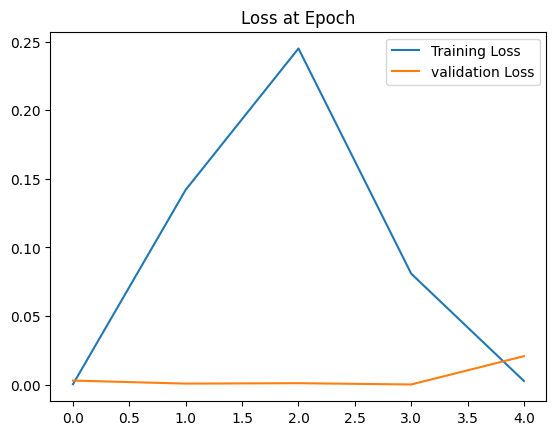

In [37]:
# Graph the loss at epoch
train_losses = [tl.item() for tl in train_losses] # convert Tesnor to Python List
plt.plot(train_losses, label="Training Loss")
plt.plot(test_losses, label="validation Loss")
plt.title("Loss at Epoch")
plt.legend()

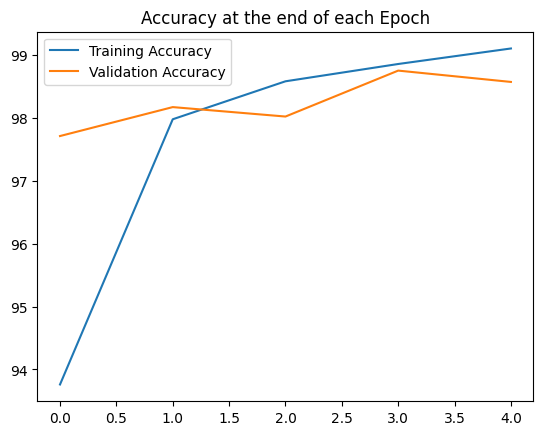

In [38]:
# Graph the accuracy at the end of each epoch
plt.plot([t/600 for t in train_correct], label="Training Accuracy")
plt.plot([t/100 for t in test_correct], label="Validation Accuracy")
plt.title("Accuracy at the end of each Epoch")
plt.legend()

In [39]:
test_load_everything = DataLoader(test_data, batch_size=10000, shuffle=False)

In [40]:
with torch.no_grad():
  correct = 0
  for X_test,y_test in test_load_everything:
    y_val = model(X_test)
    predicted = torch.max(y_val,1)[1]
    correct += (predicted == y_test).sum()

In [45]:
# Test for correct
correct.item()/len(test_data)*100

98.57000000000001

In [55]:
# Grab an image
test_data[1978] # Tensor with an image in it... at the end it shows the label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

In [56]:
# Grab just the data
test_data[1978][0]

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,

In [57]:
# Reshape it
test_data[1978][0].reshape(28,28)

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000

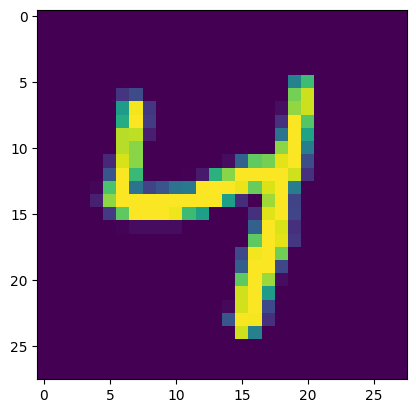

In [58]:
# show the image
plt.imshow(test_data[1978][0].reshape(28,28))

In [59]:
# Pass the image through our model
model.eval()
with torch.no_grad():
  new_prediction = model(test_data[1978][0].view(1,1,28,28)) # batch size of 1, 1 color channel, 28x28 image

In [60]:
# Check the new prediction... get probabilities
new_prediction

tensor([[-2.4992e+01, -1.8860e+01, -2.4744e+01, -3.0158e+01, -4.7684e-07,
         -2.1318e+01, -2.2632e+01, -2.0485e+01, -2.1817e+01, -1.4484e+01]])

In [61]:
new_prediction.argmax()

tensor(4)